In [2]:
import pandas as pd

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_csv("../data/raw/trainData.csv");

In [11]:
TARGET = 'loan_paid_back'

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    18000 non-null  int64  
 1   age                   18000 non-null  int64  
 2   gender                18000 non-null  str    
 3   marital_status        18000 non-null  str    
 4   education_level       18000 non-null  str    
 5   annual_income         18000 non-null  float64
 6   monthly_income        18000 non-null  float64
 7   employment_status     18000 non-null  str    
 8   debt_to_income_ratio  18000 non-null  float64
 9   credit_score          18000 non-null  int64  
 10  loan_amount           18000 non-null  float64
 11  loan_purpose          18000 non-null  str    
 12  interest_rate         18000 non-null  float64
 13  loan_term             18000 non-null  int64  
 14  installment           18000 non-null  float64
 15  num_of_open_accounts  18000 no

In [5]:
df.head()

,id,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,...,loan_purpose,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,num_of_delinquencies,loan_paid_back
0,16270,25,Male,Single,Bachelor's,30935.25,2577.94,Self-employed,0.145,619,...,Other,13.99,36,242.86,7,22945.44,17252.81,1,1,1
1,1383,67,Female,Single,Other,35542.95,2961.91,Unemployed,0.215,605,...,Other,13.18,36,394.17,3,23528.27,6637.50,2,3,0
2,3472,64,Male,Married,Master's,93830.69,7819.22,Employed,0.246,511,...,Other,19.48,36,484.51,6,88100.82,78180.71,2,2,1
3,19900,72,Female,Married,Bachelor's,21157.21,1763.10,Self-employed,0.361,683,...,Debt consolidation,14.34,60,431.97,8,28735.43,21490.58,2,3,0
4,2150,38,Male,Married,High School,33005.86,2750.49,Unemployed,0.188,643,...,Debt consolidation,12.87,36,793.00,5,28401.14,6671.40,2,3,0


In [23]:
print(df.head().to_markdown())

|    |    id |   age | gender   | marital_status   | education_level   |   annual_income |   monthly_income | employment_status   |   debt_to_income_ratio |   credit_score |   loan_amount | loan_purpose       |   interest_rate |   loan_term |   installment |   num_of_open_accounts |   total_credit_limit |   current_balance |   delinquency_history |   num_of_delinquencies |   loan_paid_back |
|---:|------:|------:|:---------|:-----------------|:------------------|----------------:|-----------------:|:--------------------|-----------------------:|---------------:|--------------:|:-------------------|----------------:|------------:|--------------:|-----------------------:|---------------------:|------------------:|----------------------:|-----------------------:|-----------------:|
|  0 | 16270 |    25 | Male     | Single           | Bachelor's        |         30935.2 |          2577.94 | Self-employed       |                  0.145 |            619 |       7106.97 | Other              |

In [20]:
df.describe()

,id,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,num_of_delinquencies,loan_paid_back
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000
mean,10002.079500,47.987833,43537.644133,3628.137003,0.176904,679.356722,15145.866243,12.400906,43.208000,456.197018,4.999611,48671.101924,24328.522198,1.987389,2.489778,0.800389
std,5776.395353,15.804223,28684.083347,2390.340291,0.104870,69.610058,8594.191326,2.441877,11.001975,274.132201,2.245069,32554.454444,22459.923569,1.470644,1.628373,0.399719
min,0.000000,21.000000,6000.000000,500.000000,0.010000,373.000000,500.000000,3.200000,36.000000,9.430000,0.000000,6157.800000,496.350000,0.000000,0.000000,0.000000
25%,4999.500000,35.000000,24253.330000,2021.115000,0.096000,633.000000,8891.350000,10.740000,36.000000,254.287500,3.000000,27195.050000,9569.262500,1.000000,1.000000,1.000000
50%,10023.500000,48.000000,36579.860000,3048.320000,0.160000,680.000000,14980.570000,12.400000,36.000000,437.610000,5.000000,40252.600000,18261.255000,2.000000,2.000000,1.000000
75%,15000.250000,62.000000,54536.292500,4544.692500,0.241000,727.000000,21003.467500,14.010000,60.000000,633.332500,6.000000,60229.410000,31656.435000,3.000000,3.000000,1.000000
max,19999.000000,75.000000,400000.000000,33333.330000,0.650000,850.000000,49039.690000,22.510000,60.000000,1685.400000,15.000000,454394.190000,352177.900000,11.000000,11.000000,1.000000


In [22]:
print(df.describe().to_markdown())

|       |      id |        age |   annual_income |   monthly_income |   debt_to_income_ratio |   credit_score |   loan_amount |   interest_rate |   loan_term |   installment |   num_of_open_accounts |   total_credit_limit |   current_balance |   delinquency_history |   num_of_delinquencies |   loan_paid_back |
|:------|--------:|-----------:|----------------:|-----------------:|-----------------------:|---------------:|--------------:|----------------:|------------:|--------------:|-----------------------:|---------------------:|------------------:|----------------------:|-----------------------:|-----------------:|
| count | 18000   | 18000      |         18000   |         18000    |           18000        |     18000      |      18000    |     18000       |   18000     |     18000     |            18000       |              18000   |          18000    |           18000       |            18000       |     18000        |
| mean  | 10002.1 |    47.9878 |         43537.6 |          3628

In [9]:
df.select_dtypes('object').nunique()

/tmp/ipykernel_42465/3198987469.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes('object').nunique()


gender               3
marital_status       4
education_level      5
employment_status    5
loan_purpose         8
dtype: int64

# Class Balance

In [12]:
print(df[TARGET].value_counts())
print(df[TARGET].value_counts(normalize=True).round(4) * 100)

loan_paid_back
1    14407
0     3593
Name: count, dtype: int64
loan_paid_back
1    80.04
0    19.96
Name: proportion, dtype: float64


# Missing Values

In [13]:
missing = pd.DataFrame({
    'count':   df.isnull().sum(),
    'percent': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('percent', ascending=False)

print(missing)

                      count  percent
id                        0      0.0
age                       0      0.0
gender                    0      0.0
marital_status            0      0.0
education_level           0      0.0
annual_income             0      0.0
monthly_income            0      0.0
employment_status         0      0.0
debt_to_income_ratio      0      0.0
credit_score              0      0.0
loan_amount               0      0.0
loan_purpose              0      0.0
interest_rate             0      0.0
loan_term                 0      0.0
installment               0      0.0
num_of_open_accounts      0      0.0
total_credit_limit        0      0.0
current_balance           0      0.0
delinquency_history       0      0.0
num_of_delinquencies      0      0.0
loan_paid_back            0      0.0


#  Numeric vs Categorical Columns

In [14]:
print("NUMERIC:")
print(df.drop(columns=[TARGET]).select_dtypes(include='number').columns.tolist())

print("\nCATEGORICAL:")
cat_cols = df.drop(columns=[TARGET]).select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} unique → {df[col].unique()[:8]}")

NUMERIC:
['id', 'age', 'annual_income', 'monthly_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'loan_term', 'installment', 'num_of_open_accounts', 'total_credit_limit', 'current_balance', 'delinquency_history', 'num_of_delinquencies']

CATEGORICAL:
  gender: 3 unique → <StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
  marital_status: 4 unique → <StringArray>
['Single', 'Married', 'Divorced', 'Widowed']
Length: 4, dtype: str
  education_level: 5 unique → <StringArray>
['Bachelor's', 'Other', 'Master's', 'High School', 'PhD']
Length: 5, dtype: str
  employment_status: 5 unique → <StringArray>
['Self-employed', 'Unemployed', 'Employed', 'Student', 'Retired']
Length: 5, dtype: str
  loan_purpose: 8 unique → <StringArray>
[             'Other', 'Debt consolidation',           'Vacation',
            'Medical',                'Car',           'Business',
          'Education',               'Home']
Length: 8, dtype: str


/tmp/ipykernel_42465/4052499320.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.drop(columns=[TARGET]).select_dtypes(include='object').columns.tolist()


# Skewness

In [15]:
num_cols = df.drop(columns=[TARGET]).select_dtypes(include='number').columns.tolist()
print(df[num_cols].skew().sort_values(ascending=False).round(3))

current_balance         2.849
total_credit_limit      2.533
monthly_income          2.343
annual_income           2.343
loan_term               0.871
delinquency_history     0.826
debt_to_income_ratio    0.781
num_of_delinquencies    0.721
installment             0.468
num_of_open_accounts    0.448
loan_amount             0.251
interest_rate           0.028
age                     0.016
id                     -0.003
credit_score           -0.076
dtype: float64


# Feature-to-Feature Correlation

                         id    age  annual_income  monthly_income  \
id                    1.000 -0.007          0.003           0.003   
age                  -0.007  1.000         -0.002          -0.002   
annual_income         0.003 -0.002          1.000           1.000   
monthly_income        0.003 -0.002          1.000           1.000   
debt_to_income_ratio -0.006  0.003          0.002           0.002   
credit_score         -0.008  0.006          0.000           0.000   
loan_amount          -0.003 -0.005          0.001           0.001   
interest_rate        -0.003  0.009         -0.002          -0.002   
loan_term             0.000  0.004          0.002           0.002   
installment          -0.004 -0.007          0.000           0.000   
num_of_open_accounts -0.004  0.002         -0.007          -0.007   
total_credit_limit    0.002  0.004          0.887           0.887   
current_balance       0.013 -0.003          0.654           0.654   
delinquency_history  -0.011  0.002

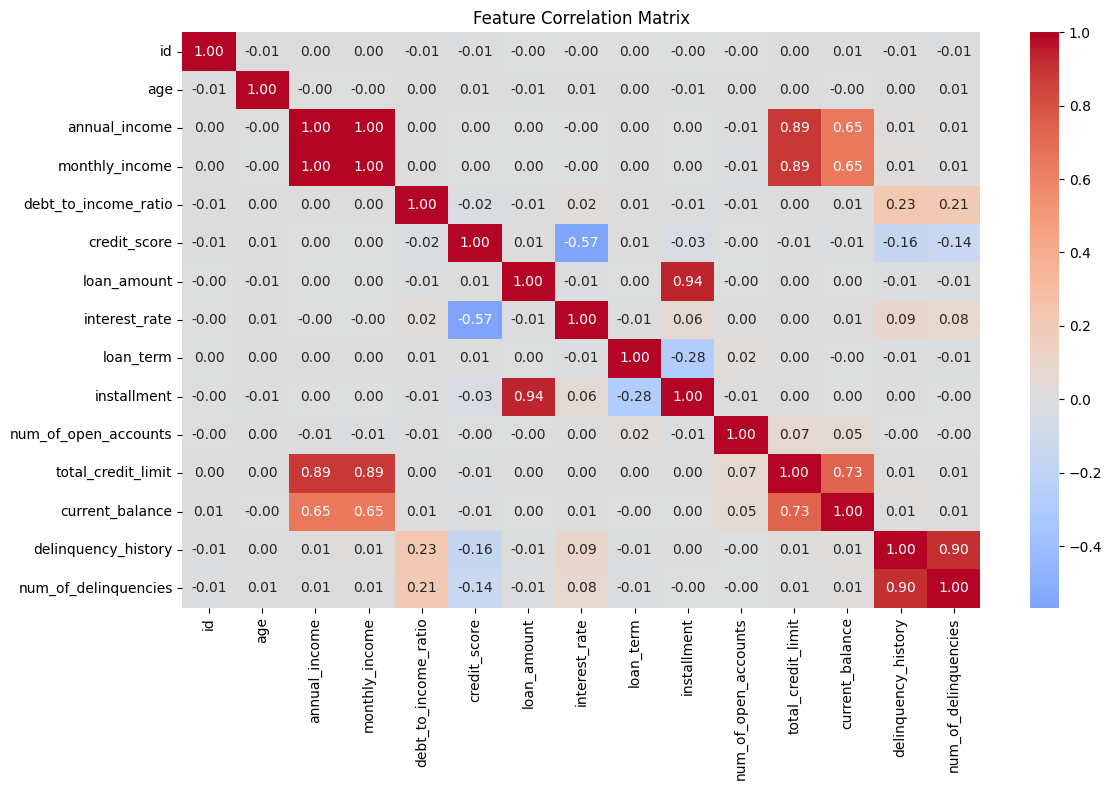

In [16]:
corr = df[num_cols].corr().round(3)
print(corr)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [25]:
print(corr.to_markdown())

|                      |     id |    age |   annual_income |   monthly_income |   debt_to_income_ratio |   credit_score |   loan_amount |   interest_rate |   loan_term |   installment |   num_of_open_accounts |   total_credit_limit |   current_balance |   delinquency_history |   num_of_delinquencies |
|:---------------------|-------:|-------:|----------------:|-----------------:|-----------------------:|---------------:|--------------:|----------------:|------------:|--------------:|-----------------------:|---------------------:|------------------:|----------------------:|-----------------------:|
| id                   |  1     | -0.007 |           0.003 |            0.003 |                 -0.006 |         -0.008 |        -0.003 |          -0.003 |       0     |        -0.004 |                 -0.004 |                0.002 |             0.013 |                -0.011 |                 -0.01  |
| age                  | -0.007 |  1     |          -0.002 |           -0.002 |            

In [24]:
# Check if monthly_income is exactly annual_income / 12
derived = (df['annual_income'] / 12).round(2)
actual = df['monthly_income'].round(2)
print("Perfectly derived?", (derived == actual).all())
print("Max difference:", (derived - actual).abs().max())

Perfectly derived? True
Max difference: 0.0


# Correlation With Target

In [17]:
# Numeric vs target
print("NUMERIC vs TARGET:")
print(df[num_cols].corrwith(df[TARGET]).abs().sort_values(ascending=False).round(3))

# Categorical vs target
print("\nCATEGORICAL vs TARGET (mean repayment rate per category):")
for col in cat_cols:
    print(f"\n{col}:")
    print(df.groupby(col)[TARGET].mean().round(3).sort_values(ascending=False))

NUMERIC vs TARGET:
debt_to_income_ratio    0.223
credit_score            0.198
interest_rate           0.107
delinquency_history     0.087
num_of_delinquencies    0.073
id                      0.014
age                     0.011
installment             0.008
num_of_open_accounts    0.004
current_balance         0.004
monthly_income          0.003
annual_income           0.003
total_credit_limit      0.002
loan_term               0.002
loan_amount             0.000
dtype: float64

CATEGORICAL vs TARGET (mean repayment rate per category):

gender:
gender
Female    0.803
Male      0.798
Other     0.785
Name: loan_paid_back, dtype: float64

marital_status:
marital_status
Divorced    0.808
Married     0.800
Single      0.800
Widowed     0.789
Name: loan_paid_back, dtype: float64

education_level:
education_level
PhD            0.825
High School    0.808
Other          0.806
Master's       0.797
Bachelor's     0.793
Name: loan_paid_back, dtype: float64

employment_status:
employment_status
R

In [26]:
# Numeric vs target
print("## NUMERIC vs TARGET (Absolute Correlation):")
print(df[num_cols].corrwith(df[TARGET]).abs().sort_values(ascending=False).round(3).to_markdown())

# Categorical vs target
print("\n## CATEGORICAL vs TARGET (Mean repayment rate per category):")
for col in cat_cols:
    print(f"\n### {col}:")
    print(df.groupby(col)[TARGET].mean().round(3).sort_values(ascending=False).to_markdown())

## NUMERIC vs TARGET (Absolute Correlation):
|                      |     0 |
|:---------------------|------:|
| debt_to_income_ratio | 0.223 |
| credit_score         | 0.198 |
| interest_rate        | 0.107 |
| delinquency_history  | 0.087 |
| num_of_delinquencies | 0.073 |
| id                   | 0.014 |
| age                  | 0.011 |
| installment          | 0.008 |
| num_of_open_accounts | 0.004 |
| current_balance      | 0.004 |
| monthly_income       | 0.003 |
| annual_income        | 0.003 |
| total_credit_limit   | 0.002 |
| loan_term            | 0.002 |
| loan_amount          | 0     |

## CATEGORICAL vs TARGET (Mean repayment rate per category):

### gender:
| gender   |   loan_paid_back |
|:---------|-----------------:|
| Female   |            0.803 |
| Male     |            0.798 |
| Other    |            0.785 |

### marital_status:
| marital_status   |   loan_paid_back |
|:-----------------|-----------------:|
| Divorced         |            0.808 |
| Married         

# Data Quality

In [18]:
print("SHAPE:", df.shape)
print("\nDTYPES:"); print(df.dtypes)
print("\nDUPLICATES:", df.duplicated().sum())
print("\nSUMMARY STATS:"); print(df.describe().T)
print("\nFIRST 5 ROWS:"); print(df.head())

SHAPE: (18000, 21)

DTYPES:
id                        int64
age                       int64
gender                      str
marital_status              str
education_level             str
annual_income           float64
monthly_income          float64
employment_status           str
debt_to_income_ratio    float64
credit_score              int64
loan_amount             float64
loan_purpose                str
interest_rate           float64
loan_term                 int64
installment             float64
num_of_open_accounts      int64
total_credit_limit      float64
current_balance         float64
delinquency_history       int64
num_of_delinquencies      int64
loan_paid_back            int64
dtype: object

DUPLICATES: 0

SUMMARY STATS:
                        count          mean           std      min  \
id                    18000.0  10002.079500   5776.395353     0.00   
age                   18000.0     47.987833     15.804223    21.00   
annual_income         18000.0  43537.644133  

In [27]:
# Shape (plain string, no conversion needed)
print(f"## SHAPE\nRows: {df.shape[0]}, Columns: {df.shape[1]}")

# Dtypes — Series, so use .to_markdown()
print("\n## DTYPES")
print(df.dtypes.to_markdown())

# Duplicates — scalar, plain print is fine
print(f"\n## DUPLICATES\n{df.duplicated().sum()}")

# Summary stats — DataFrame, use .to_markdown()
print("\n## SUMMARY STATS")
print(df.describe().T.to_markdown())

# First 5 rows — DataFrame, use .to_markdown()
print("\n## FIRST 5 ROWS")
print(df.head().to_markdown())

## SHAPE
Rows: 18000, Columns: 21

## DTYPES
|                      | 0       |
|:---------------------|:--------|
| id                   | int64   |
| age                  | int64   |
| gender               | str     |
| marital_status       | str     |
| education_level      | str     |
| annual_income        | float64 |
| monthly_income       | float64 |
| employment_status    | str     |
| debt_to_income_ratio | float64 |
| credit_score         | int64   |
| loan_amount          | float64 |
| loan_purpose         | str     |
| interest_rate        | float64 |
| loan_term            | int64   |
| installment          | float64 |
| num_of_open_accounts | int64   |
| total_credit_limit   | float64 |
| current_balance      | float64 |
| delinquency_history  | int64   |
| num_of_delinquencies | int64   |
| loan_paid_back       | int64   |

## DUPLICATES
0

## SUMMARY STATS
|                      |   count |         mean |          std |     min |       25% |      50% |       75% |      

In [28]:
df['loan_term'].value_counts()

loan_term
36    12594
60     5406
Name: count, dtype: int64